# Generator Dispatch Explorer - Notebook 1.2

**Learning objectives:**
- Understand merit order dispatch - baseload vs. peaking operation
- Identify marginal generators (price-setting units)
- Analyze capacity factors and detect outages
- Compare regional generation mixes

**Required data prep:**
```bash
uv run import_nem_data.py --start 2025/01/01 --end 2025/12/31 --dispatchload
```
Load the AEMO static registration workbook from:
https://aemo.com.au/energy-systems/electricity/national-electricity-market-nem/participate-in-the-market/registration
and save `NEM Registration and Exemption List.xlsx` into `../data/nemosis_cache/`.

**Setup note:**
- This notebook assumes the cache already exists and does not revalidate downloads inside the notebook.
- It reads cached parquet files directly rather than calling `dynamic_data_compiler`.

**Data strategy:**
DISPATCHLOAD is 90-120x larger than DISPATCHPRICE (~50M rows vs. 500K rows). Strategic sampling keeps the notebook laptop-friendly while preserving the dispatch patterns we care about.
1. **Use Polars** for lazy evaluation and efficient memory usage
2. **Read parquet files directly** from the NEMOSIS cache
3. **Strategic sampling**:
   - **One week** for merit order stacks and marginal generator analysis (~1M rows)
   - **12 weeks** (one per month) for capacity factor and regional mix (~12M rows)


In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

CACHE = Path('../data/nemosis_cache')
dispatchload_by_month = {
    f.stem.split('#')[3][:6]: f
    for f in sorted(CACHE.glob('*DISPATCHLOAD*.parquet'))
}

registration = (
    pl.from_pandas(
        pd.read_excel(
            CACHE / 'NEM Registration and Exemption List.xlsx',
            sheet_name='PU and Scheduled Loads',
            engine='openpyxl',
        )
        .assign(
            FUEL_SOURCE_PRIMARY=lambda df: df['Fuel Source - Descriptor'].fillna(df['Fuel Source - Primary']),
            REG_CAPACITY=lambda df: pd.to_numeric(df['Reg Cap generation (MW)'], errors='coerce'),
            REGIONID=lambda df: df['Region'],
            STATIONNAME=lambda df: df['Station Name'],
        )
        [['DUID', 'FUEL_SOURCE_PRIMARY', 'REG_CAPACITY', 'REGIONID', 'STATIONNAME']]
    )
    .unique(subset=['DUID'], keep='last')
    .with_columns(pl.col('FUEL_SOURCE_PRIMARY').str.strip_chars())
)

fuel_map = {
    'Brown Coal': 'Coal', 'Black Coal': 'Coal',
    'Coal Seam Methane': 'Coal', 'Waste Coal Mine Gas': 'Coal',
    'Natural Gas': 'Gas', 'Natural Gas / Fuel Oil': 'Gas',
    'Natural Gas / Diesel': 'Gas', 'Natrual Gas/ Diesel': 'Gas',
    'Diesel': 'Gas', 'Kerosene': 'Gas', 'Ethane': 'Gas',
    'Wind': 'Wind', 'Solar': 'Solar',
    'Water': 'Hydro', 'Hydro': 'Hydro',
    'Grid': 'Battery', 'Battery': 'Battery',
    'Battery Storage': 'Battery', 'Battery / Solar': 'Battery',
    'Biomass': 'Biomass', 'Bagasse': 'Biomass', 'Bagasse and Diesel': 'Biomass',
    'Landfill Methane / Landfill Gas': 'Biomass',
    'Biogas - sludge': 'Biomass', 'Sewerage / Waste Water': 'Biomass',
    'Renewable/ Biomass / Waste': 'Biomass',
    'Renewable/ Biomass / Waste and Fossil': 'Biomass',
}

registration = registration.with_columns(
    pl.col('FUEL_SOURCE_PRIMARY')
    .replace_strict(fuel_map, default='Other')
    .alias('FUEL_TYPE')
)

DISPATCH_CASTS = [
    pl.col('SETTLEMENTDATE').str.strptime(pl.Datetime, '%Y/%m/%d %H:%M:%S'),
    pl.col('INITIALMW').cast(pl.Float64),
    pl.col('INTERVENTION').cast(pl.Int32),
]

stack_order = ['Coal', 'Hydro', 'Wind', 'Solar', 'Gas', 'Battery', 'Biomass', 'Other']
stack_colors = {
    'Coal': '#4A4A4A',
    'Gas': '#FF6B6B',
    'Hydro': '#4ECDC4',
    'Wind': '#95E1D3',
    'Solar': '#FFD93D',
    'Battery': '#9D65C9',
    'Biomass': '#6BCB77',
    'Other': '#B8B8B8',
}

def load_dispatch_window(start_date, end_date):
    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')
    month_file = dispatchload_by_month[start_date[:7].replace('-', '')]
    return (
        pl.scan_parquet([month_file])
        .with_columns(DISPATCH_CASTS)
        .filter(
            (pl.col('SETTLEMENTDATE') >= start_dt) &
            (pl.col('SETTLEMENTDATE') < end_dt) &
            (pl.col('INTERVENTION') == 0)
        )
        .select([
            (pl.col('SETTLEMENTDATE') - pl.duration(minutes=5)).alias('SETTLEMENTDATE'),
            'DUID',
            pl.col('INITIALMW').alias('DISPATCHLOAD'),
        ])
        .collect()
    )

def pivot_sum(frame, index_col, category_col, value_col):
    return (
        frame
        .pivot(index=index_col, on=category_col, values=value_col, aggregate_function='sum')
        .sort(index_col)
        .fill_null(0)
    )

def present_stack_fuels(frame):
    return [fuel for fuel in stack_order if fuel in frame.columns]

print(f'DISPATCHLOAD files discovered: {len(dispatchload_by_month)}')
print(f'Registration records: {len(registration):,}')
print('Fuel types:')
print(registration.group_by('FUEL_TYPE').len().sort('len', descending=True))

DISPATCHLOAD files discovered: 13
Registration records: 563
Fuel types:
shape: (8, 2)
┌───────────┬─────┐
│ FUEL_TYPE ┆ len │
│ ---       ┆ --- │
│ str       ┆ u32 │
╞═══════════╪═════╡
│ Solar     ┆ 131 │
│ Wind      ┆ 108 │
│ Gas       ┆ 96  │
│ Hydro     ┆ 70  │
│ Coal      ┆ 63  │
│ Battery   ┆ 59  │
│ Biomass   ┆ 30  │
│ Other     ┆ 6   │
└───────────┴─────┘


For merit order stacks and marginal generator identification, we only need a **representative week** of data. This gives us ~1M rows instead of 50M — completely manageable.

Week selected: **2025-10-13 to 2025-10-20** (mid-spring: high solar, evening gas peaks, wind overnight)

In [2]:
# Representative week configuration and load
MERIT_WEEK_START = '2025-10-13'
MERIT_WEEK_END = '2025-10-20'  # Exclusive upper bound

target_files = [dispatchload_by_month[MERIT_WEEK_START[:7].replace('-', '')]]

print(f"Loading dispatch data for {MERIT_WEEK_START} to {MERIT_WEEK_END}...")
print(f"Reading from: {[f.name for f in target_files]}\n")

dispatch_week = load_dispatch_window(MERIT_WEEK_START, MERIT_WEEK_END)

print(f"Loaded {len(dispatch_week):,} rows")
print(f"Memory usage: {dispatch_week.estimated_size('mb'):.1f} MB")
print(f"Unique generators: {dispatch_week['DUID'].n_unique():,}")
print(f"Date range: {dispatch_week['SETTLEMENTDATE'].min()} to {dispatch_week['SETTLEMENTDATE'].max()}")

dispatch_week_enriched = (
    dispatch_week
    .join(
        registration.select(['DUID', 'FUEL_TYPE', 'REG_CAPACITY', 'REGIONID']),
        on='DUID',
        how='left'
    )
    .filter(pl.col('FUEL_TYPE').is_not_null())
)

print(f"Enriched data: {len(dispatch_week_enriched):,} rows")
print("\nFuel type energy (MWh):")
print(
    dispatch_week_enriched
    .group_by('FUEL_TYPE')
    .agg((pl.col('DISPATCHLOAD').sum() / 12).alias('MWh'))
    .sort('MWh', descending=True)
)


Loading dispatch data for 2025-10-13 to 2025-10-20...
Reading from: ['PUBLIC_ARCHIVE#DISPATCHLOAD#FILE01#202510010000.parquet']

Loaded 1,062,143 rows
Memory usage: 23.1 MB
Unique generators: 527
Date range: 2025-10-12 23:55:00 to 2025-10-19 23:50:00
Enriched data: 836,351 rows

Fuel type energy (MWh):
shape: (7, 2)
┌───────────┬───────────────┐
│ FUEL_TYPE ┆ MWh           │
│ ---       ┆ ---           │
│ str       ┆ f64           │
╞═══════════╪═══════════════╡
│ Coal      ┆ 1.8921e6      │
│ Wind      ┆ 566035.897912 │
│ Solar     ┆ 395230.100394 │
│ Hydro     ┆ 271190.718697 │
│ Gas       ┆ 102767.059923 │
│ Other     ┆ 32904.876137  │
│ Battery   ┆ -8306.026492  │
└───────────┴───────────────┘


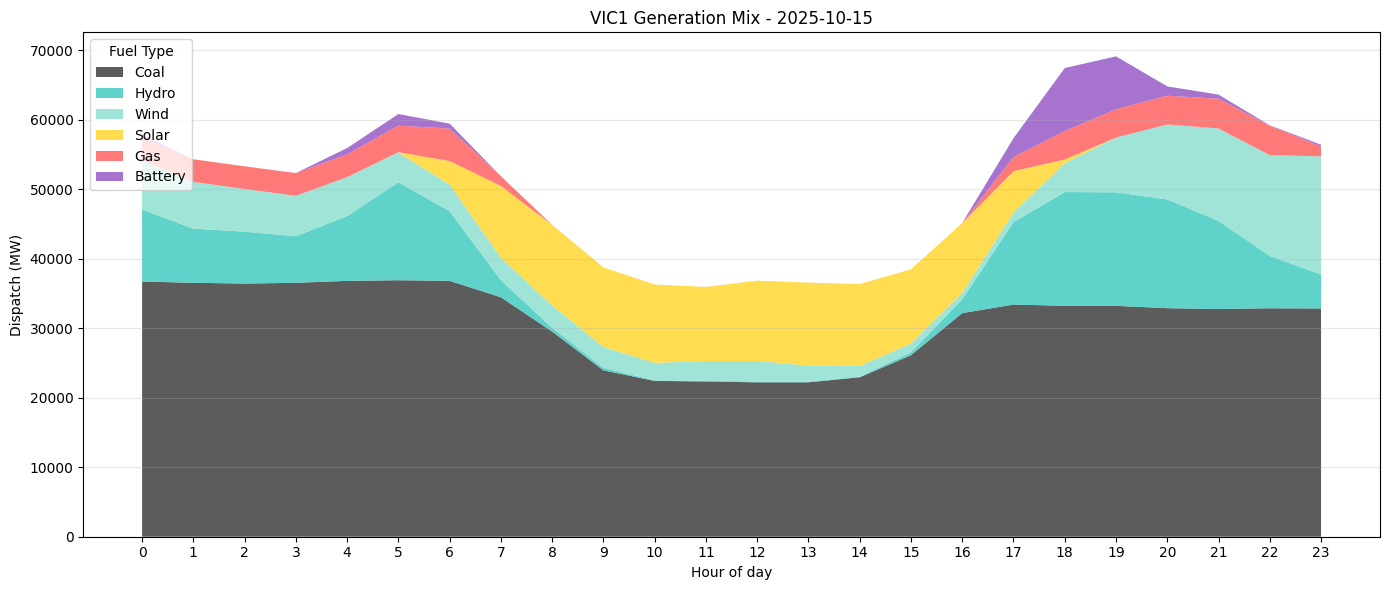

Peak demand: 69089 MW at hour 19
Min demand: 35923 MW at hour 11


In [3]:
# Merit Order Stack - VIC, single day (2025-10-15, spring Wednesday)
target_date = datetime(2025, 10, 15)
region = 'VIC1'

day_stack = (
    dispatch_week_enriched
    .filter(
        (pl.col('SETTLEMENTDATE').dt.date() == target_date.date()) &
        (pl.col('REGIONID') == region)
    )
    .with_columns(pl.col('SETTLEMENTDATE').dt.hour().alias('hour'))
    .group_by(['hour', 'FUEL_TYPE'])
    .agg(pl.col('DISPATCHLOAD').sum())
    .pipe(lambda df: pivot_sum(df, 'hour', 'FUEL_TYPE', 'DISPATCHLOAD'))
)

stack_order_present = present_stack_fuels(day_stack)
hours = day_stack['hour'].to_numpy()
stack_values = [np.clip(day_stack[fuel].to_numpy(), a_min=0, a_max=None) for fuel in stack_order_present]
total_dispatch = np.sum(stack_values, axis=0) if stack_values else np.zeros(len(hours))

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    hours,
    stack_values,
    labels=stack_order_present,
    colors=[stack_colors[fuel] for fuel in stack_order_present],
    alpha=0.9,
)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Dispatch (MW)')
ax.set_title(f'{region} Generation Mix - {target_date.strftime("%Y-%m-%d")}')
ax.legend(title='Fuel Type', loc='upper left')
ax.set_xticks(range(24))
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Peak demand: {total_dispatch.max():.0f} MW at hour {int(hours[int(total_dispatch.argmax())])}')
print(f'Min demand: {total_dispatch.min():.0f} MW at hour {int(hours[int(total_dispatch.argmin())])}')


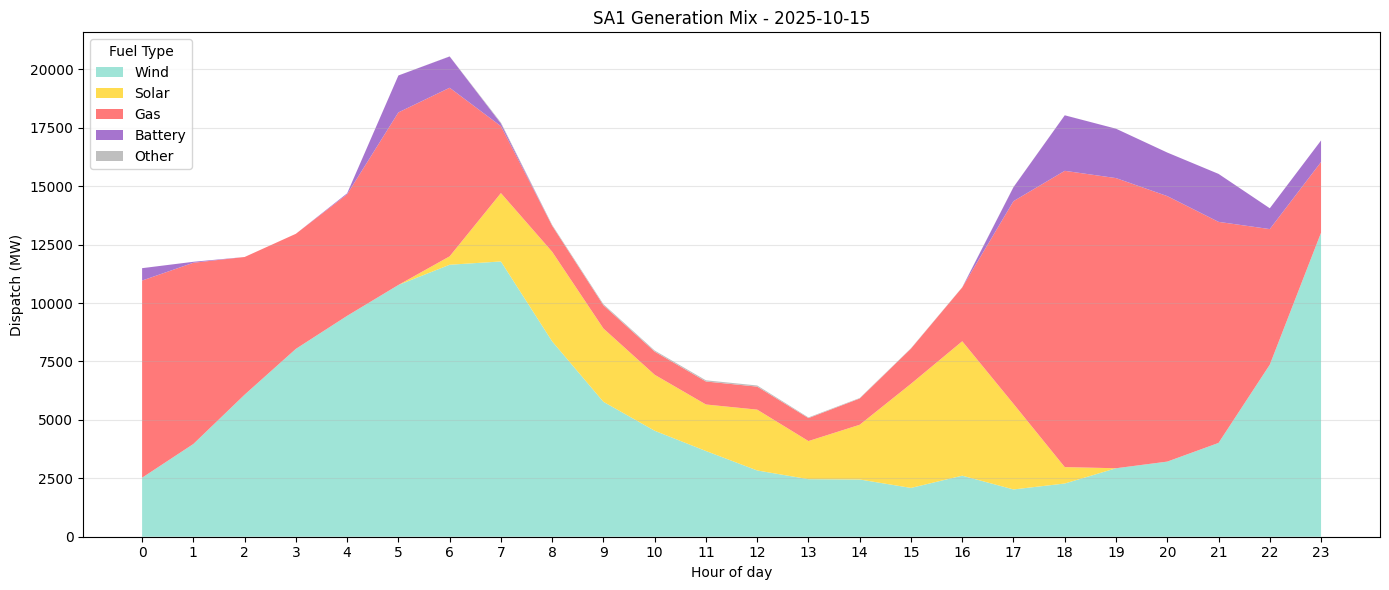

Peak demand: 20556 MW at hour 6
Min demand: 5105 MW at hour 13


In [4]:
# Merit Order Stack - SA (same day for comparison)
region = 'SA1'

day_stack = (
    dispatch_week_enriched
    .filter(
        (pl.col('SETTLEMENTDATE').dt.date() == target_date.date()) &
        (pl.col('REGIONID') == region)
    )
    .with_columns(pl.col('SETTLEMENTDATE').dt.hour().alias('hour'))
    .group_by(['hour', 'FUEL_TYPE'])
    .agg(pl.col('DISPATCHLOAD').sum())
    .pipe(lambda df: pivot_sum(df, 'hour', 'FUEL_TYPE', 'DISPATCHLOAD'))
)

stack_order_present = present_stack_fuels(day_stack)
hours = day_stack['hour'].to_numpy()
stack_values = [np.clip(day_stack[fuel].to_numpy(), a_min=0, a_max=None) for fuel in stack_order_present]
total_dispatch = np.sum(stack_values, axis=0) if stack_values else np.zeros(len(hours))

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    hours,
    stack_values,
    labels=stack_order_present,
    colors=[stack_colors[fuel] for fuel in stack_order_present],
    alpha=0.9,
)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Dispatch (MW)')
ax.set_title(f'{region} Generation Mix - {target_date.strftime("%Y-%m-%d")}')
ax.legend(title='Fuel Type', loc='upper left')
ax.set_xticks(range(24))
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Peak demand: {total_dispatch.max():.0f} MW at hour {int(hours[int(total_dispatch.argmax())])}')
print(f'Min demand: {total_dispatch.min():.0f} MW at hour {int(hours[int(total_dispatch.argmin())])}')


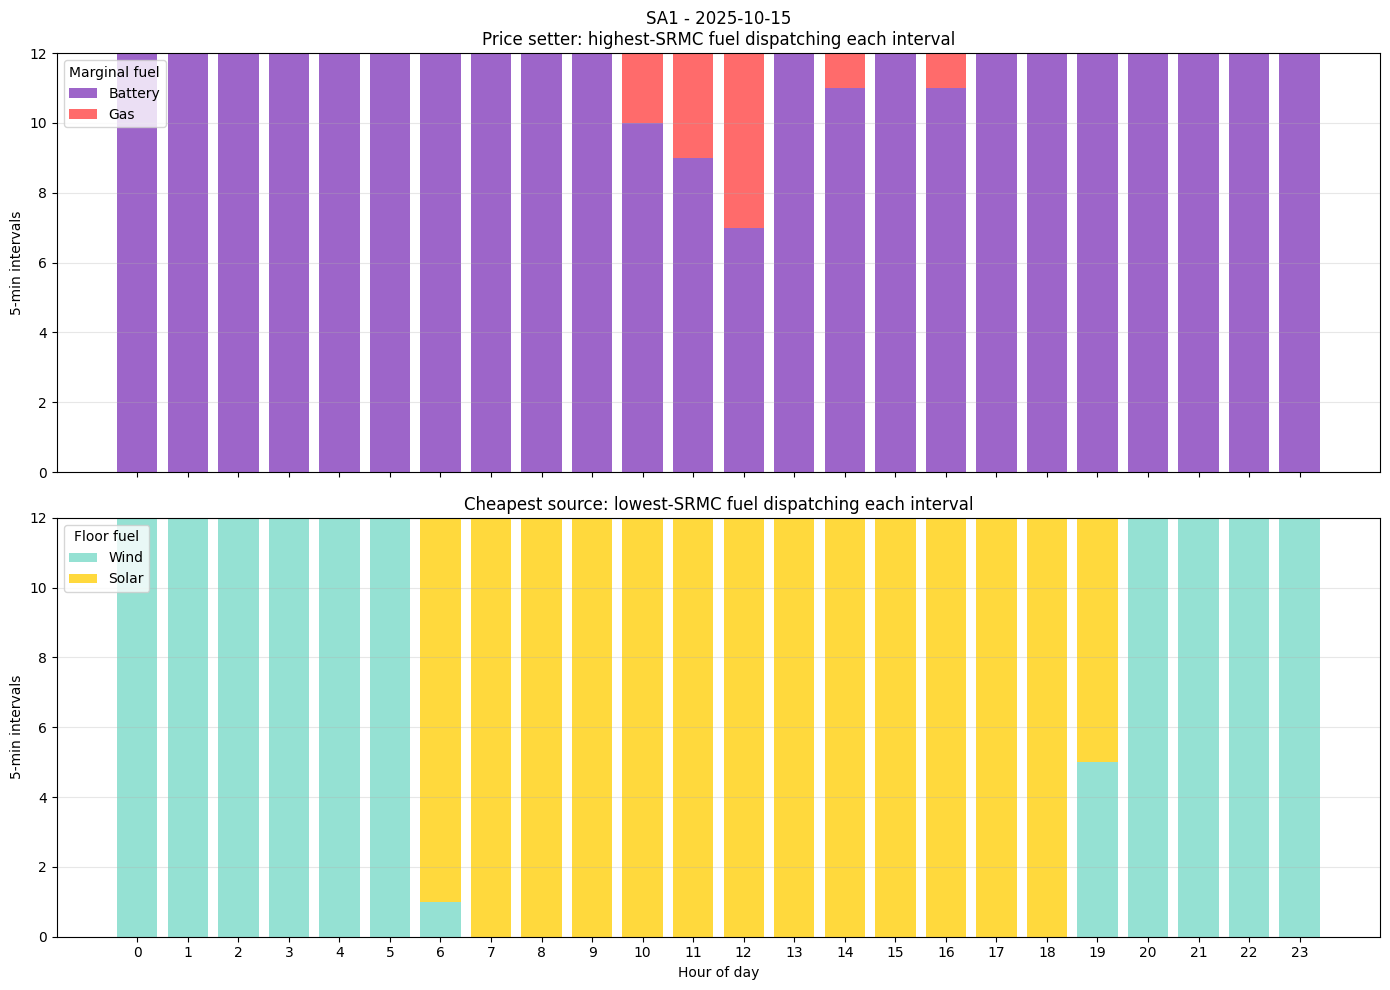

Price setter summary:
shape: (2, 2)
┌───────────────┬─────┐
│ MARGINAL_FUEL ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ Battery       ┆ 276 │
│ Gas           ┆ 12  │
└───────────────┴─────┘

Floor fuel summary:
shape: (2, 2)
┌────────────┬─────┐
│ FLOOR_FUEL ┆ len │
│ ---        ┆ --- │
│ str        ┆ u32 │
╞════════════╪═════╡
│ Solar      ┆ 162 │
│ Wind       ┆ 126 │
└────────────┴─────┘


In [5]:
# Marginal vs Floor Generator - SA, one day
# Marginal = highest-SRMC fuel dispatching (price setter)
# Floor    = lowest-SRMC fuel dispatching (cheapest source running)

region = 'SA1'

# SRMC ranking: higher = more expensive
srmc_rank = {
    'Wind': 1, 'Solar': 1,
    'Hydro': 2,
    'Coal': 3,
    'Biomass': 4,
    'Gas': 5,
    'Battery': 6,
}

day_marginal = (
    dispatch_week_enriched
    .filter(
        (pl.col('SETTLEMENTDATE').dt.date() == target_date.date()) &
        (pl.col('REGIONID') == region) &
        (pl.col('DISPATCHLOAD') > 0) &
        (pl.col('FUEL_TYPE') != 'Other')
    )
    .with_columns([
        pl.col('FUEL_TYPE').replace_strict({k: str(v) for k, v in srmc_rank.items()}, default='0').cast(pl.Int32).alias('SRMC_RANK'),
        pl.col('SETTLEMENTDATE').dt.hour().alias('hour'),
    ])
)

marginal = (
    day_marginal
    .group_by('SETTLEMENTDATE')
    .agg([
        pl.col('FUEL_TYPE').sort_by('SRMC_RANK', descending=True).first().alias('MARGINAL_FUEL'),
        pl.col('FUEL_TYPE').sort_by('SRMC_RANK', descending=False).first().alias('FLOOR_FUEL'),
        pl.col('hour').first(),
    ])
)

marginal_counts = pivot_sum(
    marginal.group_by(['hour', 'MARGINAL_FUEL']).len(),
    'hour',
    'MARGINAL_FUEL',
    'len',
)
floor_counts = pivot_sum(
    marginal.group_by(['hour', 'FLOOR_FUEL']).len(),
    'hour',
    'FLOOR_FUEL',
    'len',
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

hours = marginal_counts['hour'].to_numpy()
marginal_fuels = [col for col in marginal_counts.columns if col != 'hour']
bottom = np.zeros(len(hours))
for fuel in marginal_fuels:
    values = marginal_counts[fuel].to_numpy()
    ax1.bar(hours, values, bottom=bottom, width=0.8, color=stack_colors.get(fuel, '#B8B8B8'), label=fuel)
    bottom += values
ax1.set_ylabel('5-min intervals')
ax1.set_title(f'{region} - {target_date.strftime("%Y-%m-%d")}\nPrice setter: highest-SRMC fuel dispatching each interval')
ax1.legend(title='Marginal fuel', loc='upper left')
ax1.grid(alpha=0.3, axis='y')

hours = floor_counts['hour'].to_numpy()
floor_fuels = [col for col in floor_counts.columns if col != 'hour']
bottom = np.zeros(len(hours))
for fuel in floor_fuels:
    values = floor_counts[fuel].to_numpy()
    ax2.bar(hours, values, bottom=bottom, width=0.8, color=stack_colors.get(fuel, '#B8B8B8'), label=fuel)
    bottom += values
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('5-min intervals')
ax2.set_title('Cheapest source: lowest-SRMC fuel dispatching each interval')
ax2.legend(title='Floor fuel', loc='upper left')
ax2.set_xticks(range(24))
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Price setter summary:')
print(marginal.group_by('MARGINAL_FUEL').len().sort('len', descending=True))
print('\nFloor fuel summary:')
print(marginal.group_by('FLOOR_FUEL').len().sort('len', descending=True))


## Strategy 2: Monthly Sampling for Capacity Factor Analysis

Capacity factor requires the full year of data. Instead of loading 50M rows, we:
1. Load **one week per month** (12 weeks total)
2. Calculate weekly capacity factors
3. Extrapolate to annual estimates

This gives us ~12M rows instead of 50M — a 75% reduction while still capturing seasonal variation.

In [6]:
# Monthly sample configuration and load
sample_weeks = [
    ('2025-01-13', '2025-01-20'),
    ('2025-02-10', '2025-02-17'),
    ('2025-03-10', '2025-03-17'),
    ('2025-04-14', '2025-04-21'),
    ('2025-05-12', '2025-05-19'),
    ('2025-06-09', '2025-06-16'),
    ('2025-07-14', '2025-07-21'),
    ('2025-08-11', '2025-08-18'),
    ('2025-09-08', '2025-09-15'),
    ('2025-10-13', '2025-10-20'),
    ('2025-11-10', '2025-11-17'),
    ('2025-12-08', '2025-12-15'),
]

samples = []
for start, end in sample_weeks:
    print(f"Loading {start} to {end}...", end=' ')
    week_data = load_dispatch_window(start, end)
    samples.append(week_data)
    print(f"{len(week_data):,} rows")

dispatch_annual_sample = pl.concat(samples)
print(f"\nTotal sampled data: {len(dispatch_annual_sample):,} rows")
print(f"Memory: {dispatch_annual_sample.estimated_size('mb'):.1f} MB")


Loading 2025-01-13 to 2025-01-20... 995,615 rows
Loading 2025-02-10 to 2025-02-17... 1,003,101 rows
Loading 2025-03-10 to 2025-03-17... 1,008,000 rows
Loading 2025-04-14 to 2025-04-21... 1,021,823 rows
Loading 2025-05-12 to 2025-05-19... 1,023,839 rows
Loading 2025-06-09 to 2025-06-16... 1,030,750 rows
Loading 2025-07-14 to 2025-07-21... 1,045,152 rows
Loading 2025-08-11 to 2025-08-18... 1,050,047 rows
Loading 2025-09-08 to 2025-09-15... 1,060,415 rows
Loading 2025-10-13 to 2025-10-20... 1,062,143 rows
Loading 2025-11-10 to 2025-11-17... 1,072,223 rows
Loading 2025-12-08 to 2025-12-15... 1,087,487 rows

Total sampled data: 12,460,595 rows
Memory: 271.3 MB


In [7]:
# Enrich annual sample once - reused in capacity factor, regional mix, and monthly stack cells
dispatch_annual_sample_enriched = (
    dispatch_annual_sample
    .join(
        registration.select(['DUID', 'FUEL_TYPE', 'REG_CAPACITY', 'REGIONID']),
        on='DUID',
        how='left'
    )
    .filter(pl.col('FUEL_TYPE').is_not_null())
)

print(f"Enriched annual sample: {len(dispatch_annual_sample_enriched):,} rows")


Enriched annual sample: 9,786,808 rows


Generators with non-zero output: 368

Capacity factor by fuel type (median from sample):
shape: (7, 2)
┌───────────┬───────────┐
│ FUEL_TYPE ┆ Median_CF │
│ ---       ┆ ---       │
│ str       ┆ f64       │
╞═══════════╪═══════════╡
│ Coal      ┆ 0.607164  │
│ Hydro     ┆ 0.286728  │
│ Wind      ┆ 0.260735  │
│ Other     ┆ 0.193953  │
│ Solar     ┆ 0.158282  │
│ Battery   ┆ 0.057615  │
│ Gas       ┆ 0.022036  │
└───────────┴───────────┘


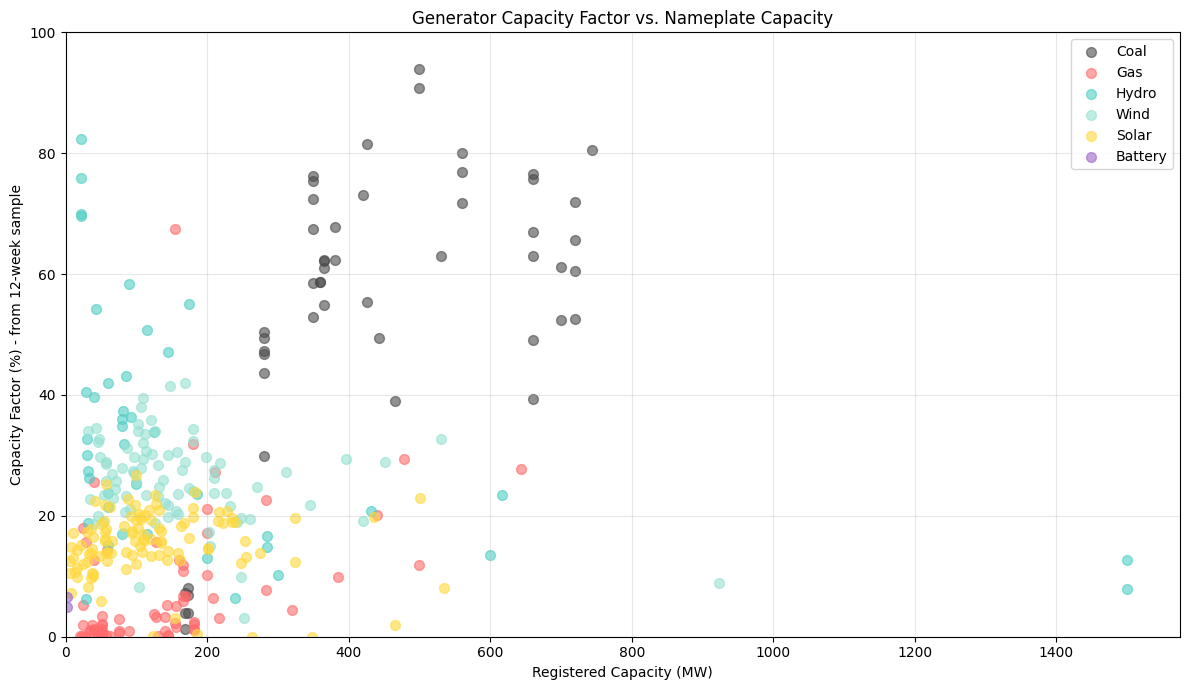

In [8]:
# Calculate capacity factors from sampled data
energy_by_duid = (
    dispatch_annual_sample_enriched
    .group_by('DUID')
    .agg([
        pl.col('DISPATCHLOAD').sum().alias('TOTAL_DISPATCH'),
        pl.col('REG_CAPACITY').first(),
        pl.col('FUEL_TYPE').first(),
        pl.col('REGIONID').first(),
    ])
)

sample_intervals = len(samples) * 7 * 24 * 12

energy_by_duid = (
    energy_by_duid
    .with_columns((pl.col('TOTAL_DISPATCH') / (pl.col('REG_CAPACITY') * sample_intervals)).alias('CF_SAMPLE'))
    .filter((pl.col('REG_CAPACITY') > 0) & (pl.col('TOTAL_DISPATCH') > 0))
)

print(f'Generators with non-zero output: {len(energy_by_duid)}')
print('\nCapacity factor by fuel type (median from sample):')
cf_by_fuel = (
    energy_by_duid
    .group_by('FUEL_TYPE')
    .agg(pl.col('CF_SAMPLE').median().alias('Median_CF'))
    .sort('Median_CF', descending=True)
)
print(cf_by_fuel)

fig, ax = plt.subplots(figsize=(12, 7))
for fuel in ['Coal', 'Gas', 'Hydro', 'Wind', 'Solar', 'Battery']:
    subset = energy_by_duid.filter(pl.col('FUEL_TYPE') == fuel)
    if len(subset) > 0:
        ax.scatter(
            subset['REG_CAPACITY'].to_numpy(),
            subset['CF_SAMPLE'].to_numpy() * 100,
            label=fuel,
            color=stack_colors.get(fuel, '#B8B8B8'),
            alpha=0.6,
            s=50,
        )

ax.set_xlabel('Registered Capacity (MW)')
ax.set_ylabel('Capacity Factor (%) - from 12-week sample')
ax.set_title('Generator Capacity Factor vs. Nameplate Capacity')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, None)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


In [9]:
# Identify low-CF coal units (potential outages)
coal_units = energy_by_duid.filter(pl.col('FUEL_TYPE') == 'Coal').sort('CF_SAMPLE')
low_cf = coal_units.filter(pl.col('CF_SAMPLE') < 0.5)

print('Coal units with capacity factor < 50%:')
print(low_cf.select(['DUID', 'REG_CAPACITY', 'CF_SAMPLE', 'REGIONID']))

if len(low_cf) > 0:
    print('\nThese units may have experienced extended outages.')
else:
    print('\nAll coal units operated at normal capacity factors.')


Coal units with capacity factor < 50%:
shape: (15, 4)
┌──────────┬──────────────┬───────────┬──────────┐
│ DUID     ┆ REG_CAPACITY ┆ CF_SAMPLE ┆ REGIONID │
│ ---      ┆ ---          ┆ ---       ┆ ---      │
│ str      ┆ f64          ┆ f64       ┆ str      │
╞══════════╪══════════════╪═══════════╪══════════╡
│ BRAEMAR2 ┆ 168.0        ┆ 0.013422  ┆ QLD1     │
│ BRAEMAR6 ┆ 173.0        ┆ 0.038946  ┆ QLD1     │
│ BRAEMAR3 ┆ 168.0        ┆ 0.039951  ┆ QLD1     │
│ BRAEMAR7 ┆ 173.0        ┆ 0.068725  ┆ QLD1     │
│ BRAEMAR1 ┆ 168.0        ┆ 0.073127  ┆ QLD1     │
│ …        ┆ …            ┆ …         ┆ …        │
│ GSTONE4  ┆ 280.0        ┆ 0.467505  ┆ QLD1     │
│ GSTONE2  ┆ 280.0        ┆ 0.472602  ┆ QLD1     │
│ BW04     ┆ 660.0        ┆ 0.490163  ┆ NSW1     │
│ GSTONE5  ┆ 280.0        ┆ 0.49391   ┆ QLD1     │
│ TNPS1    ┆ 443.0        ┆ 0.494128  ┆ QLD1     │
└──────────┴──────────────┴───────────┴──────────┘

These units may have experienced extended outages.


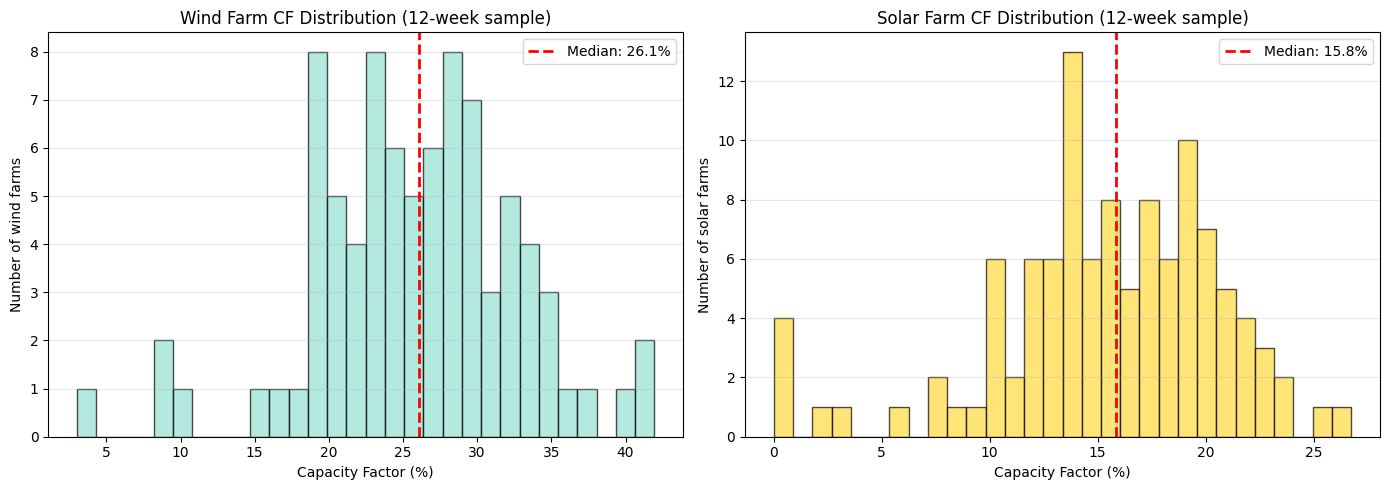

Wind: 84 farms, median = 26.1%
Solar: 110 farms, median = 15.8%


In [10]:
# Wind and Solar CF distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wind_cf = energy_by_duid.filter(pl.col('FUEL_TYPE') == 'Wind')['CF_SAMPLE'].to_numpy() * 100
axes[0].hist(wind_cf, bins=30, color=stack_colors['Wind'], edgecolor='black', alpha=0.7)
axes[0].axvline(np.median(wind_cf), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(wind_cf):.1f}%')
axes[0].set_xlabel('Capacity Factor (%)')
axes[0].set_ylabel('Number of wind farms')
axes[0].set_title('Wind Farm CF Distribution (12-week sample)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

solar_cf = energy_by_duid.filter(pl.col('FUEL_TYPE') == 'Solar')['CF_SAMPLE'].to_numpy() * 100
axes[1].hist(solar_cf, bins=30, color=stack_colors['Solar'], edgecolor='black', alpha=0.7)
axes[1].axvline(np.median(solar_cf), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(solar_cf):.1f}%')
axes[1].set_xlabel('Capacity Factor (%)')
axes[1].set_ylabel('Number of solar farms')
axes[1].set_title('Solar Farm CF Distribution (12-week sample)')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Wind: {len(wind_cf)} farms, median = {np.median(wind_cf):.1f}%')
print(f'Solar: {len(solar_cf)} farms, median = {np.median(solar_cf):.1f}%')


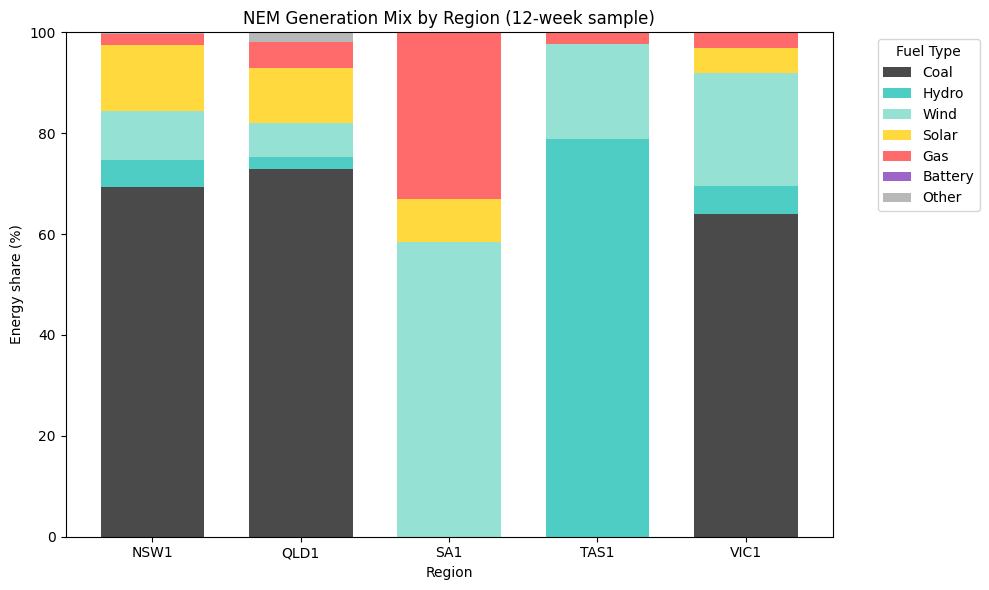


Regional generation mix (%):
shape: (5, 8)
┌──────────┬──────┬───────┬──────┬───────┬──────┬─────────┬───────┐
│ REGIONID ┆ Coal ┆ Hydro ┆ Wind ┆ Solar ┆ Gas  ┆ Battery ┆ Other │
│ ---      ┆ ---  ┆ ---   ┆ ---  ┆ ---   ┆ ---  ┆ ---     ┆ ---   │
│ str      ┆ f64  ┆ f64   ┆ f64  ┆ f64   ┆ f64  ┆ f64     ┆ f64   │
╞══════════╪══════╪═══════╪══════╪═══════╪══════╪═════════╪═══════╡
│ NSW1     ┆ 69.3 ┆ 5.5   ┆ 9.7  ┆ 13.0  ┆ 2.5  ┆ -0.2    ┆ 0.3   │
│ QLD1     ┆ 72.9 ┆ 2.5   ┆ 6.7  ┆ 10.9  ┆ 5.2  ┆ -0.1    ┆ 1.9   │
│ SA1      ┆ 0.0  ┆ 0.0   ┆ 58.3 ┆ 8.6   ┆ 33.7 ┆ -0.6    ┆ 0.1   │
│ TAS1     ┆ 0.0  ┆ 78.8  ┆ 18.8 ┆ 0.0   ┆ 2.4  ┆ 0.0     ┆ 0.0   │
│ VIC1     ┆ 63.9 ┆ 5.6   ┆ 22.3 ┆ 5.1   ┆ 3.3  ┆ -0.2    ┆ 0.0   │
└──────────┴──────┴───────┴──────┴───────┴──────┴─────────┴───────┘


In [11]:
# Regional generation mix from annual sample
regional_mix = (
    dispatch_annual_sample_enriched
    .group_by(['REGIONID', 'FUEL_TYPE'])
    .agg(pl.col('DISPATCHLOAD').sum())
    .pipe(lambda df: pivot_sum(df, 'REGIONID', 'FUEL_TYPE', 'DISPATCHLOAD'))
)

stack_order_present = present_stack_fuels(regional_mix)
regions = regional_mix['REGIONID'].to_list()
mix_values = np.column_stack([regional_mix[fuel].to_numpy() for fuel in stack_order_present])
regional_mix_pct = mix_values / mix_values.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(regions))
for idx, fuel in enumerate(stack_order_present):
    values = regional_mix_pct[:, idx]
    ax.bar(regions, values, bottom=bottom, color=stack_colors[fuel], width=0.7, label=fuel)
    bottom += values

ax.set_xlabel('Region')
ax.set_ylabel('Energy share (%)')
ax.set_title('NEM Generation Mix by Region (12-week sample)')
ax.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

regional_mix_pct_df = pl.DataFrame({'REGIONID': regions, **{fuel: regional_mix_pct[:, idx] for idx, fuel in enumerate(stack_order_present)}})
print('\nRegional generation mix (%):')
print(regional_mix_pct_df.with_columns(pl.exclude('REGIONID').round(1)))


Top 20 generators (from 12-week sample):
shape: (20, 6)
┌───────┬───────────┬──────────┬──────────────┬─────────────┬───────────┐
│ DUID  ┆ FUEL_TYPE ┆ REGIONID ┆ REG_CAPACITY ┆ ENERGY_GWh  ┆ CF_SAMPLE │
│ ---   ┆ ---       ┆ ---      ┆ ---          ┆ ---         ┆ ---       │
│ str   ┆ str       ┆ str      ┆ f64          ┆ f64         ┆ f64       │
╞═══════╪═══════════╪══════════╪══════════════╪═════════════╪═══════════╡
│ KPP_1 ┆ Coal      ┆ QLD1     ┆ 744.0        ┆ 1207.463154 ┆ 0.805027  │
│ ER02  ┆ Coal      ┆ NSW1     ┆ 720.0        ┆ 1044.649456 ┆ 0.719693  │
│ BW01  ┆ Coal      ┆ NSW1     ┆ 660.0        ┆ 1018.920946 ┆ 0.765784  │
│ BW03  ┆ Coal      ┆ NSW1     ┆ 660.0        ┆ 1006.797074 ┆ 0.756672  │
│ ER03  ┆ Coal      ┆ NSW1     ┆ 720.0        ┆ 953.447849  ┆ 0.656862  │
│ …     ┆ …         ┆ …        ┆ …            ┆ …           ┆ …         │
│ MP1   ┆ Coal      ┆ NSW1     ┆ 700.0        ┆ 739.736657  ┆ 0.52419   │
│ MPP_1 ┆ Coal      ┆ QLD1     ┆ 426.0        ┆ 699.8294

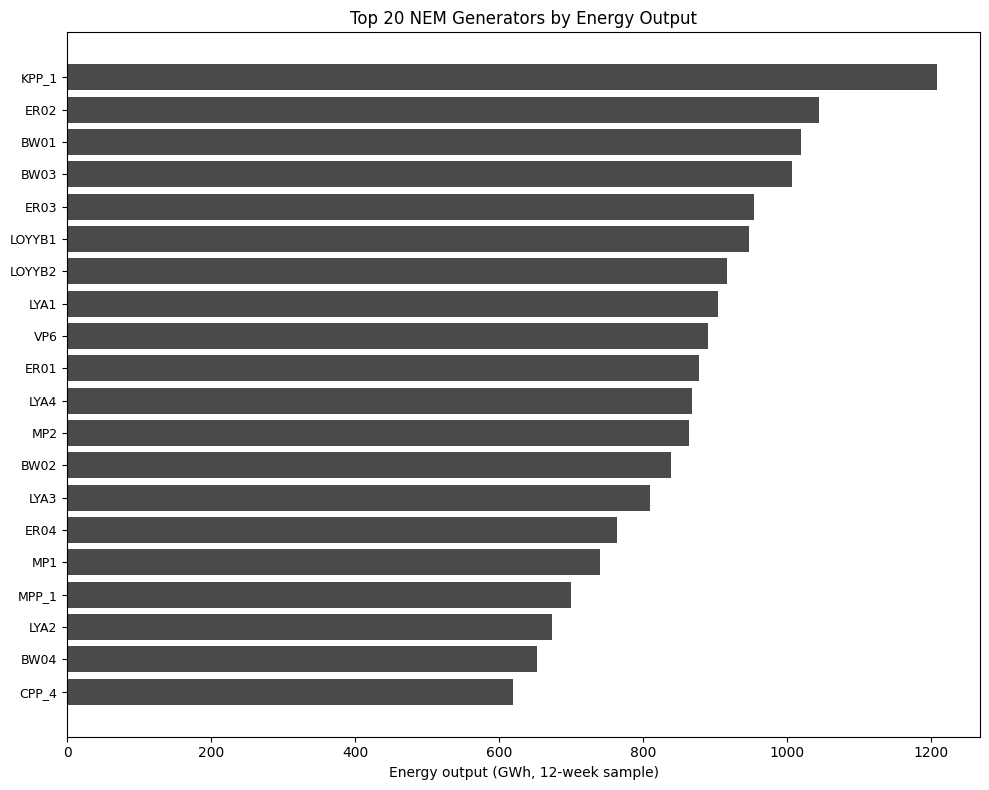

In [12]:
# Top 20 generators by energy output (from sample)
top_20 = (
    energy_by_duid
    .sort('TOTAL_DISPATCH', descending=True)
    .head(20)
    .with_columns((pl.col('TOTAL_DISPATCH') / 12 / 1000).alias('ENERGY_GWh'))
)

print('Top 20 generators (from 12-week sample):')
print(top_20.select(['DUID', 'FUEL_TYPE', 'REGIONID', 'REG_CAPACITY', 'ENERGY_GWh', 'CF_SAMPLE']))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    range(len(top_20)),
    top_20['ENERGY_GWh'].to_numpy(),
    color=[stack_colors.get(fuel, '#B8B8B8') for fuel in top_20['FUEL_TYPE'].to_list()],
)

ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['DUID'].to_list(), fontsize=9)
ax.set_xlabel('Energy output (GWh, 12-week sample)')
ax.set_title('Top 20 NEM Generators by Energy Output')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


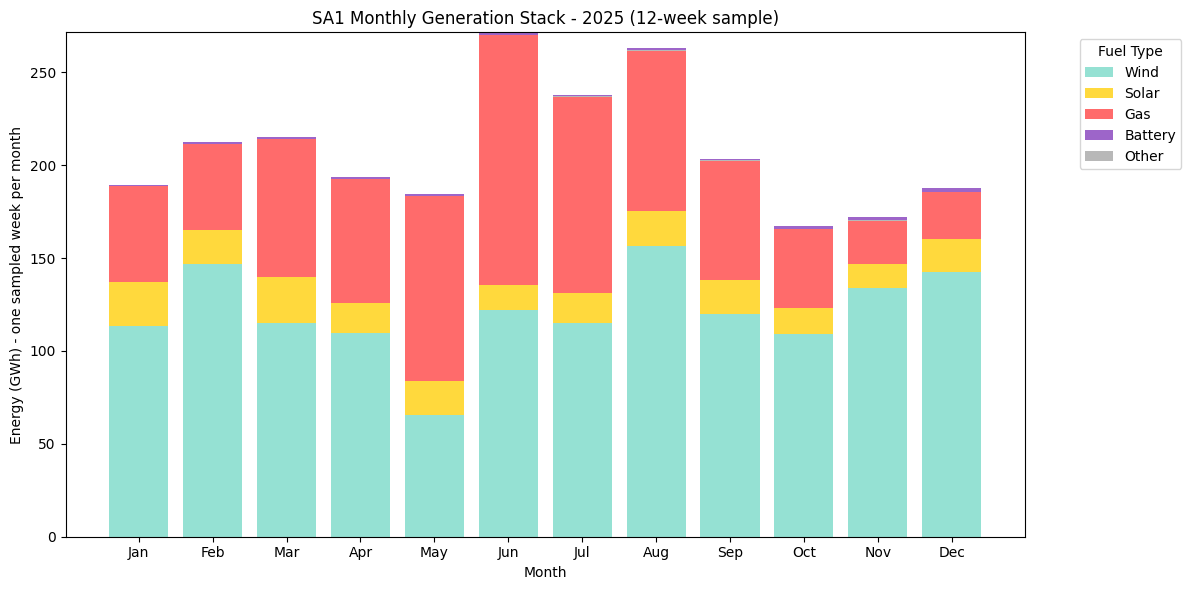

Monthly energy by fuel type (GWh, from sampled week):
shape: (12, 6)
┌───────┬───────┬───────┬───────┬─────────┬───────┐
│ month ┆ Wind  ┆ Solar ┆ Gas   ┆ Battery ┆ Other │
│ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---     ┆ ---   │
│ i8    ┆ f64   ┆ f64   ┆ f64   ┆ f64     ┆ f64   │
╞═══════╪═══════╪═══════╪═══════╪═════════╪═══════╡
│ 1     ┆ 113.4 ┆ 23.8  ┆ 52.4  ┆ -1.0    ┆ 0.2   │
│ 2     ┆ 146.8 ┆ 18.1  ┆ 47.4  ┆ -0.9    ┆ 0.1   │
│ 3     ┆ 114.9 ┆ 25.1  ┆ 75.1  ┆ -0.8    ┆ 0.2   │
│ 4     ┆ 109.7 ┆ 15.9  ┆ 68.3  ┆ -1.5    ┆ 0.1   │
│ 5     ┆ 65.4  ┆ 18.5  ┆ 100.8 ┆ -1.2    ┆ 0.1   │
│ …     ┆ …     ┆ …     ┆ …     ┆ …       ┆ …     │
│ 8     ┆ 156.5 ┆ 18.8  ┆ 87.7  ┆ -1.2    ┆ 0.1   │
│ 9     ┆ 119.9 ┆ 18.3  ┆ 65.4  ┆ -1.1    ┆ 0.1   │
│ 10    ┆ 109.1 ┆ 14.1  ┆ 44.0  ┆ -1.5    ┆ 0.1   │
│ 11    ┆ 133.8 ┆ 13.2  ┆ 24.9  ┆ -1.7    ┆ 0.1   │
│ 12    ┆ 142.7 ┆ 17.6  ┆ 27.6  ┆ -2.4    ┆ 0.1   │
└───────┴───────┴───────┴───────┴─────────┴───────┘


In [13]:
# Monthly Dispatch Stack - SA1
# Shows how the generation mix in SA shifts month-to-month.
# Wind resource is strongest in winter; solar peaks in summer;
# gas fills the gaps. Each bar represents one sampled week scaled
# to approximate monthly energy, so magnitudes are relative.

region = 'SA1'

monthly_stack = (
    dispatch_annual_sample_enriched
    .filter(pl.col('REGIONID') == region)
    .with_columns(pl.col('SETTLEMENTDATE').dt.month().alias('month'))
    .group_by(['month', 'FUEL_TYPE'])
    .agg(pl.col('DISPATCHLOAD').sum())
    .pipe(lambda df: pivot_sum(df, 'month', 'FUEL_TYPE', 'DISPATCHLOAD'))
)

stack_order_present = present_stack_fuels(monthly_stack)
months = monthly_stack['month'].to_numpy()
monthly_gwh = np.column_stack([monthly_stack[fuel].to_numpy() / 12 / 1000 for fuel in stack_order_present])
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(months))
for idx, fuel in enumerate(stack_order_present):
    values = monthly_gwh[:, idx]
    ax.bar(months, values, bottom=bottom, color=stack_colors[fuel], width=0.8, label=fuel)
    bottom += values

ax.set_xlabel('Month')
ax.set_ylabel('Energy (GWh) - one sampled week per month')
ax.set_title(f'{region} Monthly Generation Stack - 2025 (12-week sample)')
ax.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticks(months)
ax.set_xticklabels([month_labels[i - 1] for i in months], rotation=0)
plt.tight_layout()
plt.show()

monthly_stack_gwh_df = pl.DataFrame({'month': months, **{fuel: monthly_gwh[:, idx] for idx, fuel in enumerate(stack_order_present)}})
print('Monthly energy by fuel type (GWh, from sampled week):')
print(monthly_stack_gwh_df.with_columns(pl.exclude('month').round(1)))
